<a href="https://colab.research.google.com/github/Raju-mia-RK/DeepLearning/blob/main/VisionTransform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torchvision
from torchvision import datasets
import torch.nn as nn
from torchvision.transforms import ToTensor

In [4]:
train_data=datasets.FashionMNIST(
    root='data',
    train=True,
    transform=ToTensor(),
    target_transform=None,
    download=True
)
test_data=datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=ToTensor()
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 224kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.19MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.2MB/s]


In [9]:
image,label=train_data[0]
image,shape

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
image.shape

torch.Size([1, 28, 28])

In [7]:
class_names=train_data.classes

In [8]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Visualizing our data

<function matplotlib.pyplot.show(close=None, block=None)>

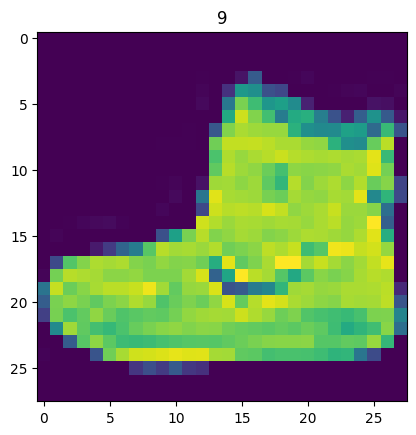

In [10]:
plt.imshow(image.squeeze())
plt.title(label)
plt.show

Text(0.5, 1.0, 'Ankle boot')

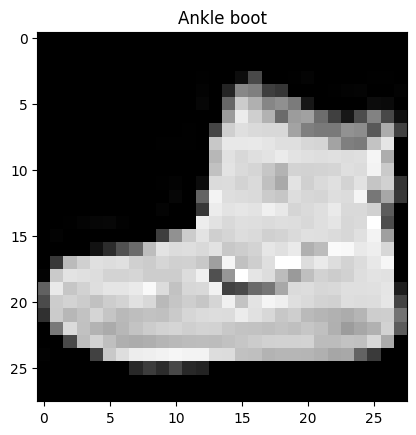

In [12]:
plt.imshow(image.squeeze_(),cmap='gray')
plt.title(class_names[label])

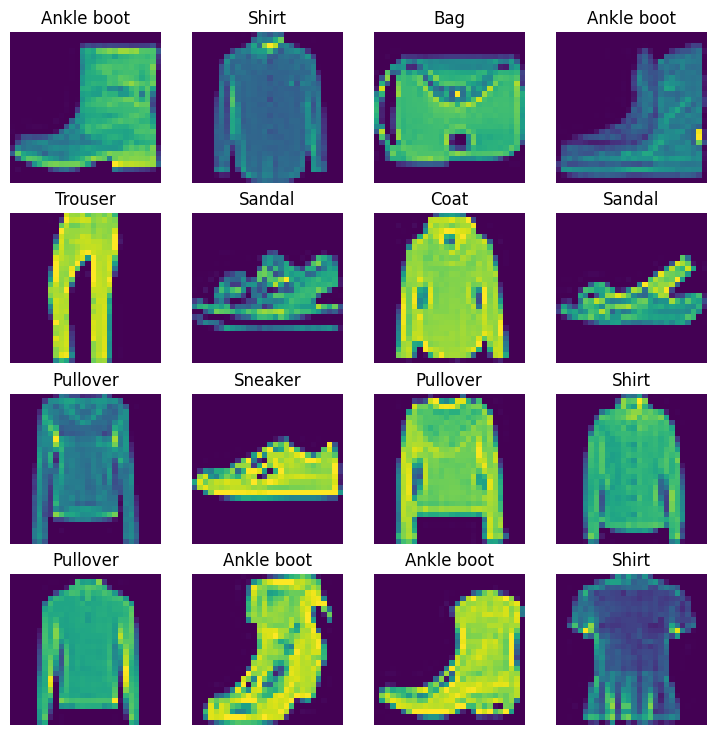

In [17]:
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  img,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(img.squeeze())
  plt.title(class_names[label])
  plt.axis(False)

DataLoader

In [20]:
from torch.utils.data import DataLoader
Batch_size=32

train_dataloader=DataLoader(train_data,
    batch_size=Batch_size,
    shuffle=True
)
test_dataloader=DataLoader(test_data,
    batch_size=Batch_size,
    shuffle=False
)

print(f'Dataloaders: {train_dataloader,test_dataloader}')
print(f"Length of train dataloader: {len(train_dataloader)}")
print(f"Length of test dataloader: {len(test_dataloader)}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7a23af9e4140>, <torch.utils.data.dataloader.DataLoader object at 0x7a23cc419040>)
Length of train dataloader: 1875
Length of test dataloader: 313


In [21]:
train_features_batch,train_label_batch=next(iter(train_dataloader))
train_features_batch.shape,train_label_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

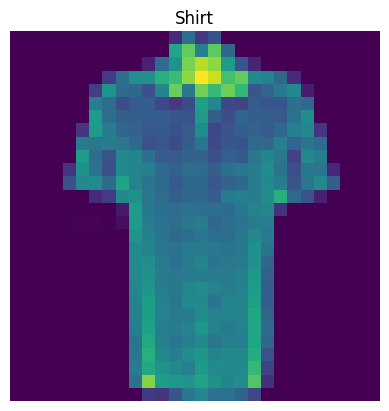

In [22]:
torch.manual_seed(42)

random_idx=torch.randint(0,len(train_features_batch),size=[1]).item()
img,label=train_features_batch[random_idx],train_label_batch[random_idx]
plt.imshow(img.squeeze())
plt.title(class_names[label])
plt.axis('Off')


In [23]:
flatten_model=nn.Flatten()

x=train_features_batch[0]
output=flatten_model(x)

x.shape,output.shape

(torch.Size([1, 28, 28]), torch.Size([1, 784]))

model

In [25]:
class FashionMNISTModel(nn.Module):
  def __init__(self,input_shape,output_shape,hidden_units):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
        )
  def forward(self,x):
    return self.layer_stack(x)

In [27]:
torch.manual_seed(42)
model0=FashionMNISTModel(input_shape=784,output_shape=len(class_names),hidden_units=10)
device='cuda' if torch.cuda.is_available() else 'cpu'
model0.to(device)

FashionMNISTModel(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [31]:
import requests
from pathlib import Path

if Path('helper_functions.py').is_file():
  print("helper_functions.py already exists,skipping download")
else:
  print('Downloading helper_functions.py')
  request=requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open('helper_functions.py','wb') as f:
    f.write(request.content)

In [32]:
from helper_functions import accuracy_fn

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model0.parameters(),lr=0.1)

traning loop

In [37]:
from tqdm.auto import tqdm
from timeit import default_timer as timer
torch.manual_seed(42)
train_time_start_on_cpu=timer()
epochs=3

for epoch in tqdm(range(epochs)):
  train_loss=0
  for batch,(X,y) in enumerate(train_dataloader):
    model0.train()
    y_pred=model0(X)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch%400 ==0:
      print(f'Looked at {batch *len(X)}/{len(train_dataloader.dataset)} samples')
  train_loss/=len(train_dataloader)

  test_loss,test_acc=0,0
  model0.eval()
  with torch.inference_mode():
    for X,y in test_dataloader:

      test_pred=model0(X)
      test_loss+=loss_fn(test_pred,y)
      test_pred_labels = torch.argmax(test_pred, dim=1)
      test_acc+=accuracy_fn(y_true=y,y_pred=test_pred_labels)
    test_loss/=len(test_dataloader)
    test_acc/=len(test_dataloader)
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%\n")

train_time_end_on_cpu=timer()

  0%|          | 0/3 [00:00<?, ?it/s]

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.43611 | Test loss: 0.46329, Test acc: 83.71%

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.43170 | Test loss: 0.46319, Test acc: 83.96%

Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples

Train loss: 0.42640 | Test loss: 0.46448, Test acc: 83.94%

